In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###EXTRA

In [1]:
!git clone https://github.com/masterAristocats/Proc-Sin-Trabalho-Extra.git

Cloning into 'Proc-Sin-Trabalho-Extra'...
remote: Enumerating objects: 189, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 189 (delta 9), reused 2 (delta 2), pack-reused 162 (from 1)
Receiving objects: 100% (189/189), 11.35 MiB | 16.74 MiB/s, done.
Resolving deltas: 100% (78/78), done.


In [2]:
%cd Proc-Sin-Trabalho-Extra

!ls src

/content/Proc-Sin-Trabalho-Extra
beamformer.py	generate_uca.py   generate_ula.py  steering_vector.py
beampattern.py	generate_ucya.py  generate_upa.py


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from src.generate_ula import generate_ula
from src.steering_vector import steering_vector
from src.beamformer import beamformer

In [9]:
# Constantes
c = 3e8
fc = 1e9
wavelength = c / fc

# Arranjo
M = 8
d = wavelength / 2

# Posições da ULA
positions = generate_ula(M, d)

##Gerar dois sinais

In [10]:
fs = 20000

t = np.arange(
    0,
    0.01,
    1/fs
)

# Fonte 1
s1 = (
    np.sin(2*np.pi*500*t)
    +
    0.5*np.sin(2*np.pi*1500*t)
)

# Fonte 2
s2 = (
    np.sin(2*np.pi*500*t)
    +
    0.5*np.sin(2*np.pi*1500*t)
)

##Direções de chegada

In [11]:
theta1 = np.deg2rad(-20)

theta2 = np.deg2rad(40)

##Recepção do arranjo

In [12]:
a1 = steering_vector(
    positions,
    theta1,
    0,
    wavelength
)

a2 = steering_vector(
    positions,
    theta2,
    0,
    wavelength
)

x = (
    a1[:, np.newaxis] * s1
    +
    a2[:, np.newaxis] * s2
)

##Capacidade de separação angular

In [14]:
theta_scan = np.linspace(-90, 90, 181)

power = []

for angle in theta_scan:

    y = np.zeros(len(t), dtype=complex)

    for i in range(len(t)):

        y[i] = beamformer(
            x[:, i],
            positions,                  # <-- aqui
            (np.deg2rad(angle), 0),
            wavelength
        )

    power.append(
        np.mean(np.abs(y) ** 2)
    )

power = np.array(power)

power /= np.max(power)

power_db = 10 * np.log10(np.maximum(power, 1e-12))

##Gráfico

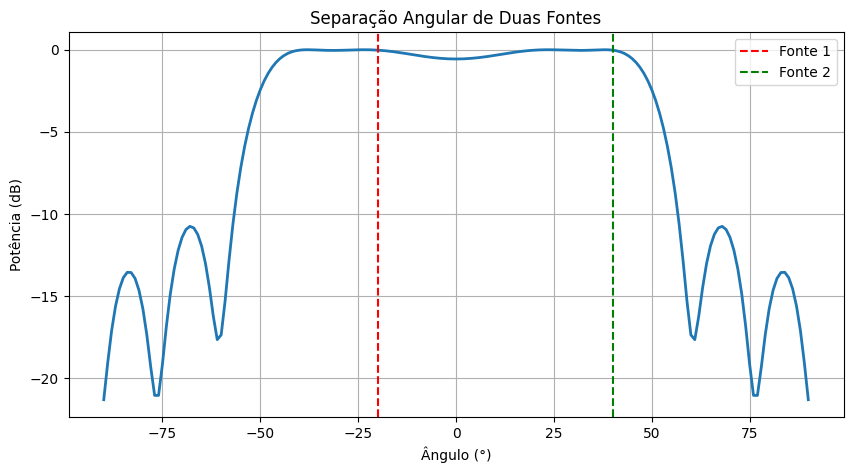

In [15]:
plt.figure(figsize=(10,5))

plt.plot(
    theta_scan,
    power_db,
    linewidth=2
)

plt.axvline(-20,color="red",ls="--",label="Fonte 1")

plt.axvline(40,color="green",ls="--",label="Fonte 2")

plt.grid(True)

plt.legend()

plt.xlabel("Ângulo (°)")
plt.ylabel("Potência (dB)")

plt.title("Separação Angular de Duas Fontes")

plt.show()

##Influência do número de sensores

In [16]:
sensor_list = [4,8,16]

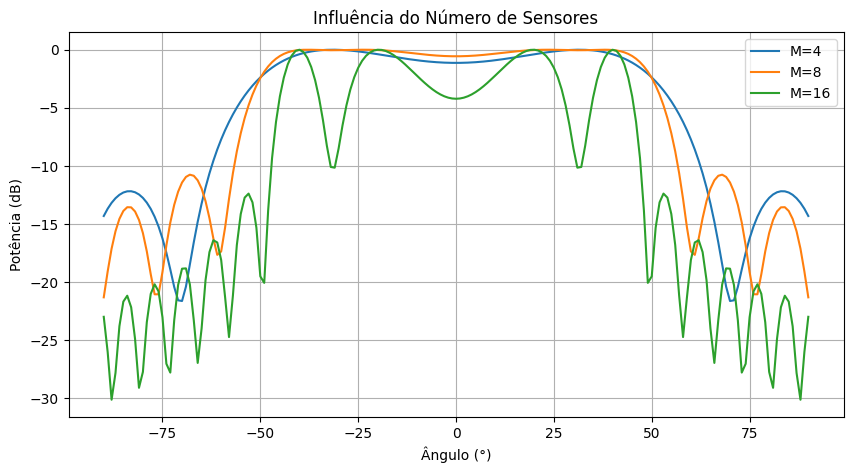

In [17]:
plt.figure(figsize=(10,5))

for M in sensor_list:

    positions = generate_ula(
        M,
        wavelength/2
    )

    a1 = steering_vector(
        positions,
        theta1,
        0,
        wavelength
    )

    a2 = steering_vector(
        positions,
        theta2,
        0,
        wavelength
    )

    x = (
        a1[:,None]*s1
        +
        a2[:,None]*s2
    )

    power=[]

    for angle in theta_scan:

        y=np.zeros(len(t),dtype=complex)

        for i in range(len(t)):

            y[i]=beamformer(
                x[:,i],
                positions,
                (np.deg2rad(angle),0),
                wavelength
            )

        power.append(
            np.mean(np.abs(y)**2)
        )

    power=np.array(power)

    power/=power.max()

    plt.plot(
        theta_scan,
        10*np.log10(np.maximum(power,1e-12)),
        label=f"M={M}"
    )

plt.grid(True)

plt.legend()

plt.title("Influência do Número de Sensores")

plt.xlabel("Ângulo (°)")
plt.ylabel("Potência (dB)")

plt.show()

##Influência do espaçamento

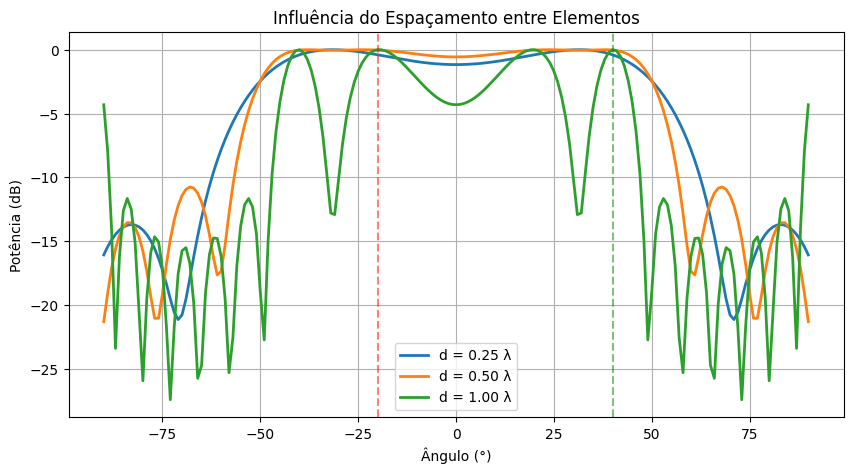

In [18]:
# ===============================
# Influência do espaçamento
# ===============================

M = 8

d_values = [
    wavelength / 4,
    wavelength / 2,
    wavelength
]

plt.figure(figsize=(10, 5))

for d in d_values:

    positions = generate_ula(M, d)

    a1 = steering_vector(
        positions,
        theta1,
        0,
        wavelength
    )

    a2 = steering_vector(
        positions,
        theta2,
        0,
        wavelength
    )

    x = (
        a1[:, np.newaxis] * s1
        +
        a2[:, np.newaxis] * s2
    )

    power = []

    for angle in theta_scan:

        y = np.zeros(len(t), dtype=complex)

        for i in range(len(t)):

            y[i] = beamformer(
                x[:, i],
                positions,
                (np.deg2rad(angle), 0),
                wavelength
            )

        power.append(
            np.mean(np.abs(y) ** 2)
        )

    power = np.array(power)

    power /= np.max(power)

    power_db = 10 * np.log10(
        np.maximum(power, 1e-12)
    )

    plt.plot(
        theta_scan,
        power_db,
        linewidth=2,
        label=f"d = {d / wavelength:.2f} λ"
    )

plt.axvline(
    np.rad2deg(theta1),
    color="red",
    linestyle="--",
    alpha=0.5
)

plt.axvline(
    np.rad2deg(theta2),
    color="green",
    linestyle="--",
    alpha=0.5
)

plt.grid(True)

plt.xlabel("Ângulo (°)")
plt.ylabel("Potência (dB)")

plt.title("Influência do Espaçamento entre Elementos")

plt.legend()

plt.show()

##Limitações do beamformer convencional

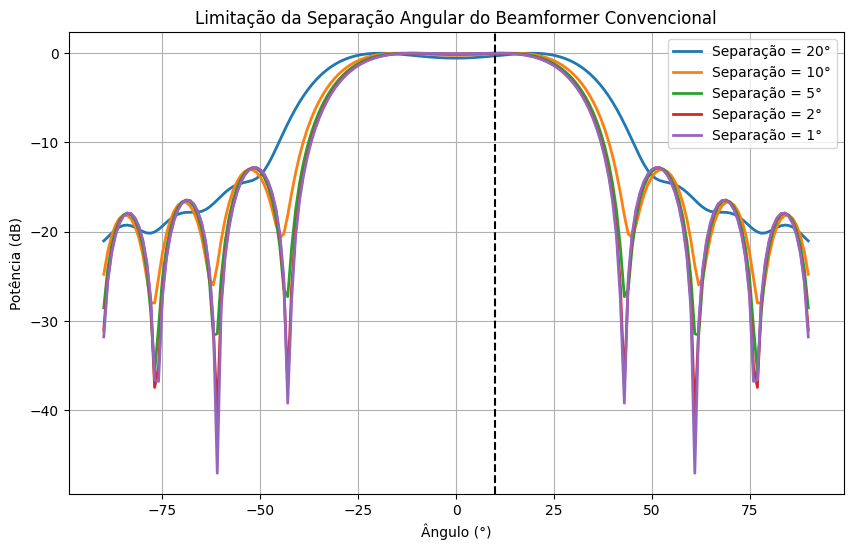

In [19]:
# ===============================
# Limitações do Beamformer
# ===============================

M = 8

positions = generate_ula(
    M,
    wavelength / 2
)

theta1 = np.deg2rad(10)

theta2_list = [
    np.deg2rad(30),
    np.deg2rad(20),
    np.deg2rad(15),
    np.deg2rad(12),
    np.deg2rad(11)
]

plt.figure(figsize=(10, 6))

for theta2 in theta2_list:

    s1 = np.sin(2 * np.pi * 500 * t)

    s2 = 0.8 * np.sin(2 * np.pi * 1200 * t)

    a1 = steering_vector(
        positions,
        theta1,
        0,
        wavelength
    )

    a2 = steering_vector(
        positions,
        theta2,
        0,
        wavelength
    )

    x = (
        a1[:, np.newaxis] * s1
        +
        a2[:, np.newaxis] * s2
    )

    power = []

    for angle in theta_scan:

        y = np.zeros(len(t), dtype=complex)

        for i in range(len(t)):

            y[i] = beamformer(
                x[:, i],
                positions,
                (np.deg2rad(angle), 0),
                wavelength
            )

        power.append(
            np.mean(np.abs(y) ** 2)
        )

    power = np.array(power)

    power /= np.max(power)

    power_db = 10 * np.log10(
        np.maximum(power, 1e-12)
    )

    plt.plot(
        theta_scan,
        power_db,
        linewidth=2,
        label=f"Separação = {np.rad2deg(theta2 - theta1):.0f}°"
    )

plt.axvline(
    np.rad2deg(theta1),
    color="black",
    linestyle="--"
)

plt.grid(True)

plt.xlabel("Ângulo (°)")
plt.ylabel("Potência (dB)")

plt.title("Limitação da Separação Angular do Beamformer Convencional")

plt.legend()

plt.show()